In [11]:
import weatherduck
import fiddle.graphviz
import fiddle as fdl

## Visualising the config

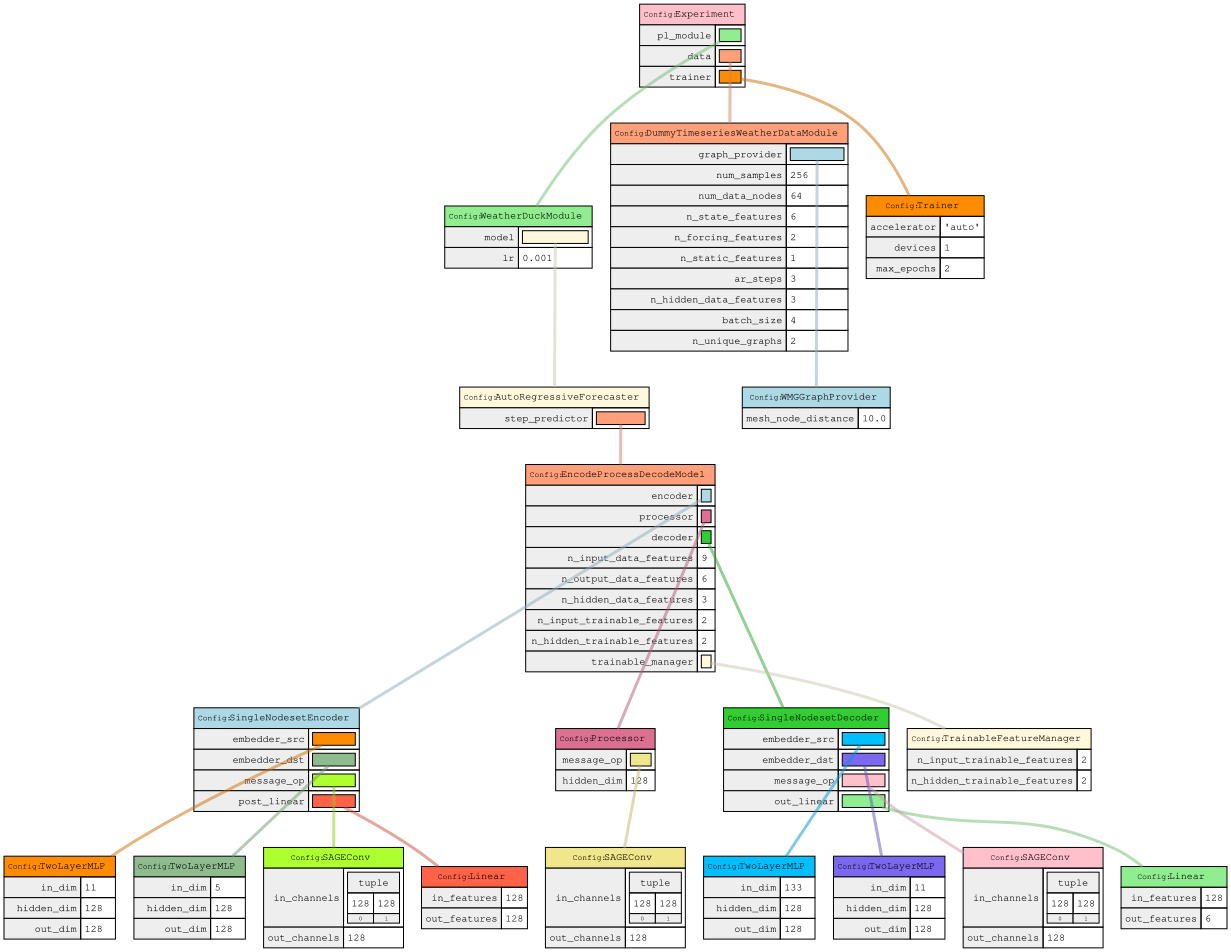

In [12]:
cfg = weatherduck.autoregressive_experiment_factory.as_buildable()
fiddle.graphviz.render(cfg)

## Overriding part of the config

In [14]:
cfg.pl_module.model.step_predictor.decoder

<Config[SingleNodesetDecoder(
  embedder_src=<Config[TwoLayerMLP(in_dim=133, hidden_dim=128, out_dim=128)]>,
  embedder_dst=<Config[TwoLayerMLP(in_dim=11, hidden_dim=128, out_dim=128)]>,
  message_op=<Config[SAGEConv(in_channels=(128, 128), out_channels=128)]>,
  out_linear=<Config[Linear(in_features=128, out_features=6)]>)]>

In [15]:
import torch
# overriding some config values
cfg.data.batch_size = 42
cfg.pl_module.model.step_predictor.encoder.embedder_src = fdl.Config(torch.nn.Linear, 11, 128)
cfg.trainer.max_epochs = 10
exp = fdl.build(cfg)
print(exp)
# run the experiment with exp.run()

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores


Experiment(pl_module=WeatherDuckModule(
  (model): AutoRegressiveForecaster(
    (step_predictor): EncodeProcessDecodeModel(
      (encoder): SingleNodesetEncoder(
        (embedder_src): Linear(in_features=11, out_features=128, bias=True)
        (embedder_dst): TwoLayerMLP(
          (net): Sequential(
            (0): Linear(in_features=5, out_features=128, bias=True)
            (1): GELU(approximate='none')
            (2): Linear(in_features=128, out_features=128, bias=True)
          )
        )
        (message_op): SAGEConv((128, 128), 128, aggr=mean)
        (post): Linear(in_features=128, out_features=128, bias=True)
        (activation): GELU(approximate='none')
      )
      (processor): Processor(
        (message_op): SAGEConv((128, 128), 128, aggr=mean)
        (mlp): Sequential(
          (0): GELU(approximate='none')
          (1): Linear(in_features=128, out_features=128, bias=True)
          (2): GELU(approximate='none')
        )
      )
      (decoder): SingleNode

## Outputting config to YAML (e.g. for mlflow logging)

In [16]:
from fiddle.experimental.yaml_serialization import dump_yaml

In [17]:
print(dump_yaml(cfg))

!fdl.Config
__fn_or_cls__:
  module: weatherduck.configs
  name: Experiment
data: !fdl.Config
  __fn_or_cls__:
    module: weatherduck.data.dummy
    name: DummyTimeseriesWeatherDataModule
  ar_steps: 3
  batch_size: 42
  graph_provider: !fdl.Config
    __fn_or_cls__:
      module: weatherduck.graphs.wmg
      name: WMGGraphProvider
    mesh_node_distance: 10.0
  n_forcing_features: 2
  n_hidden_data_features: 3
  n_state_features: 6
  n_static_features: 1
  n_unique_graphs: 2
  num_data_nodes: 64
  num_samples: 256
pl_module: !fdl.Config
  __fn_or_cls__:
    module: weatherduck.lightning
    name: WeatherDuckModule
  lr: 0.001
  model: !fdl.Config
    __fn_or_cls__:
      module: weatherduck.ar_forecaster
      name: AutoRegressiveForecaster
    step_predictor: !fdl.Config
      __fn_or_cls__:
        module: weatherduck.step_predictor
        name: EncodeProcessDecodeModel
      decoder: !fdl.Config
        __fn_or_cls__:
          module: weatherduck.step_predictor
          name: S